## Эксперименты, часть 2

### Бустинг + стилометрия

In [1]:
import pandas as pd
from catboost import CatBoostClassifier
import re
from collections import Counter
import squarify
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import optuna
from optuna.samplers import TPESampler

In [2]:
def plot_metrics(y_train_true, y_train_pred, y_val_true, y_val_pred):
    # Матрицы ошибок
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    conf_matrix_train = confusion_matrix(y_train_true, y_train_pred)
    sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок (train)')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.subplot(1, 2, 2)
    conf_matrix_val = confusion_matrix(y_val_true, y_val_pred)
    sns.heatmap(conf_matrix_val, annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок (valid)')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.show()

    # Отчёты о классификации
    report_train = classification_report(y_train_true, y_train_pred, output_dict=True)
    report_val = classification_report(y_val_true, y_val_pred, output_dict=True)

    df_report_train = pd.DataFrame(report_train).transpose()
    df_report_val = pd.DataFrame(report_val).transpose()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(df_report_train.iloc[:-1, :].T, annot=True, fmt='.2f', cmap='GnBu')
    plt.title('Отчёт о классификации (train)')

    plt.subplot(1, 2, 2)
    sns.heatmap(df_report_val.iloc[:-1, :].T, annot=True, fmt='.2f', cmap='GnBu')
    plt.title('Отчёт о классификации (valid)')

    plt.tight_layout()
    plt.show()

In [3]:
def plot_curves(y_true, y_pred_proba, dataset, n_classes=3):
    fpr, tpr, roc_auc = dict(), dict(), dict()
    
    # ROC-кривая
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    for i in range(n_classes):
        mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation
    mean_tpr /= n_classes

    fpr = fpr_grid
    tpr = mean_tpr
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='purple', label=f'AUC (ROC) = {roc_auc:.4f}')
    plt.fill_between(fpr, tpr, alpha=0.2, color='purple')
    plt.plot([0, 1], [0, 1], linestyle='--', color='dodgerblue', label='Кривая для случайного классификатора (y=х)')
    plt.title(f'ROC-кривая ({dataset})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()

In [4]:
df = pd.read_parquet('df.parquet')

In [5]:
def delete_stopwords(tokens):
    cleaned = []
    for word in tokens:
        if word not in stop_words:
            cleaned.append(word)
    return cleaned

In [6]:
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vladkopchev/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vladkopchev/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vladkopchev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
train_df = pd.read_parquet('train.parquet').iloc[:, [2, 1]]
val_df = pd.read_parquet('val.parquet').iloc[:, [2, 1]]
test_df = pd.read_parquet('test.parquet').iloc[:, [2, 1]]

In [28]:
train_df['cleaned_value'] = train_df.value.str.replace(r'[^a-zA-Z\s]', '', regex=True)
val_df['cleaned_value'] = val_df.value.str.replace(r'[^a-zA-Z\s]', '', regex=True)
test_df['cleaned_value'] = test_df.value.str.replace(r'[^a-zA-Z\s]', '', regex=True)

In [29]:
train_df['tokens'] = train_df.cleaned_value.apply(word_tokenize)
val_df['tokens'] = val_df.cleaned_value.apply(word_tokenize)
test_df['tokens'] = test_df.cleaned_value.apply(word_tokenize)

In [30]:
train_df['cleaned_tokens'] = train_df['tokens'].apply(delete_stopwords)
val_df['cleaned_tokens'] = val_df['tokens'].apply(delete_stopwords)
test_df['cleaned_tokens'] = test_df['tokens'].apply(delete_stopwords)

In [31]:
def lemmatize_tokens(tokens):
    lemmatized = []
    for word in tokens:
        lemmatized.append(lemmatizer.lemmatize(word))
    return lemmatized

train_df['lemmatized'] = train_df['cleaned_tokens'].apply(lemmatize_tokens)
val_df['lemmatized'] = val_df['cleaned_tokens'].apply(lemmatize_tokens)
test_df['lemmatized'] = test_df['cleaned_tokens'].apply(lemmatize_tokens)

In [32]:
X_train = train_df.iloc[:, 0]
y_train = train_df.iloc[:, 1].replace({'human_output': 0, 'model_output': 1, 'human_edits': 2})

X_val = val_df.iloc[:, 0]
y_val = val_df.iloc[:, 1].replace({'human_output': 0, 'model_output': 1, 'human_edits': 2})

X_test = test_df.iloc[:, 0]
y_test = test_df.iloc[:, 1].replace({'human_output': 0, 'model_output': 1, 'human_edits': 2})

/var/folders/0k/pk7zyw6x2sqcjpbqvgf0ssh80000gn/T/ipykernel_16022/356371258.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = train_df.iloc[:, 1].replace({'human_output': 0, 'model_output': 1, 'human_edits': 2})
/var/folders/0k/pk7zyw6x2sqcjpbqvgf0ssh80000gn/T/ipykernel_16022/356371258.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_val = val_df.iloc[:, 1].replace({'human_output': 0, 'model_output': 1, 'human_edits': 2})
/var/folders/0k/pk7zyw6x2sqcjpbqvgf0ssh80000gn/T/ipykernel_16022/356371258.py:8: FutureWarning

**Теперь делаем фичи**

In [34]:
import spacy

In [35]:
from scipy.sparse import hstack, csr_matrix

In [36]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=['parser', 'senter', 'ner', 'lemmatizer'],
    enable=['tok2vec', 'tagger', 'attribute_ruler']
)

In [37]:
nlp.add_pipe('sentencizer')

In [38]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(1,3), max_features=10000)

In [39]:
def stylometric_feature_extractor(text):
    tokenized = nlp(text)
    words_lst = [token.text.lower() for token in tokenized if not token.is_punct]
    paragraphs_lst = [p.strip() for p in text.split('\n\n') if p.strip()]

    word_cnt = len(words_lst)
    char_cnt = len(text)
    tags_cnt = Counter(token.pos_ for token in tokenized)

    unique_words_cnt = len(set(words_lst))
    sentences_lengths = [len(s) for s in list(tokenized.sents)]
    paragraphs_lengths = [len(p.split()) for p in paragraphs_lst]

    hapax_cnt = sum(1 for c in Counter(words_lst).values() if c == 1)
    words_cntr = Counter(words_lst)

    return {
        'words_cnt': word_cnt,
        'sentences_cnt': len(list(tokenized.sents)),
        'ttr': unique_words_cnt / word_cnt if word_cnt != 0 else 0,
        'hapax_rate': hapax_cnt / word_cnt if word_cnt != 0 else 0,
        'unique_rate': unique_words_cnt / word_cnt if word_cnt != 0 else 0,
        'unique_word_rate': unique_words_cnt / word_cnt if word_cnt != 0 else 0,
        'mean_word_length': np.mean([len(w) for w in words_lst]) if word_cnt != 0 else 0,
        'repetition_rate': sum(1 for c in words_cntr.values() if c > 2) / len(words_cntr) if len(words_lst) else 0
    }

def stylometric_vectorizer(X):
    return pd.DataFrame(X.apply(stylometric_feature_extractor).tolist())

In [40]:
%%time
X_train_lemmatized = vectorizer.fit_transform(X_train)
X_val_lemmatized = vectorizer.transform(X_val)
X_test_lemmatized = vectorizer.transform(X_test)

X_train_stylometric = stylometric_vectorizer(X_train)
X_val_stylometric = stylometric_vectorizer(X_val)
X_test_stylometric = stylometric_vectorizer(X_test)

CPU times: user 2min 14s, sys: 1.61 s, total: 2min 16s
Wall time: 2min 16s


In [41]:
X_train_combined = hstack([X_train_lemmatized, csr_matrix(X_train_stylometric.values)])
X_val_combined = hstack([X_val_lemmatized, csr_matrix(X_val_stylometric.values)])
X_test_combined = hstack([X_test_lemmatized, csr_matrix(X_test_stylometric.values)])

Обучение

In [55]:
%%time

model_catboost_bow = CatBoostClassifier(
    **{'n_estimators': 410, 'max_depth': 2, 'learning_rate': 0.015308851092125, 'min_data_in_leaf': 6}, 
    random_state=42, verbose=False
)
model_catboost_bow.fit(X_train_combined, y_train)

CPU times: user 4min 7s, sys: 3.1 s, total: 4min 10s
Wall time: 47.9 s


In [56]:
y_train_pred = model_catboost_bow.predict(X_train_combined)
y_val_pred = model_catboost_bow.predict(X_val_combined)

In [57]:
y_train_pred_proba = model_catboost_bow.predict_proba(X_train_combined)
y_val_pred_proba = model_catboost_bow.predict_proba(X_val_combined)

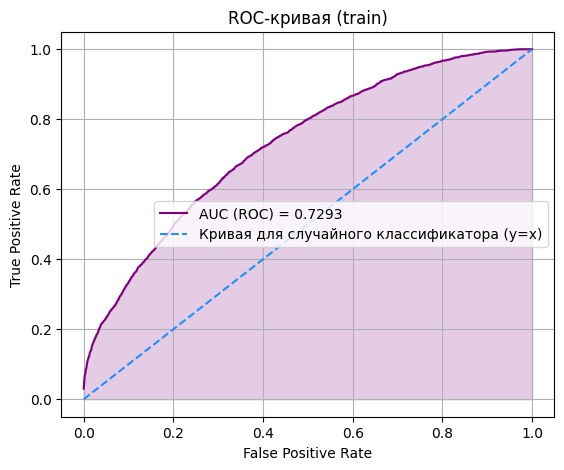

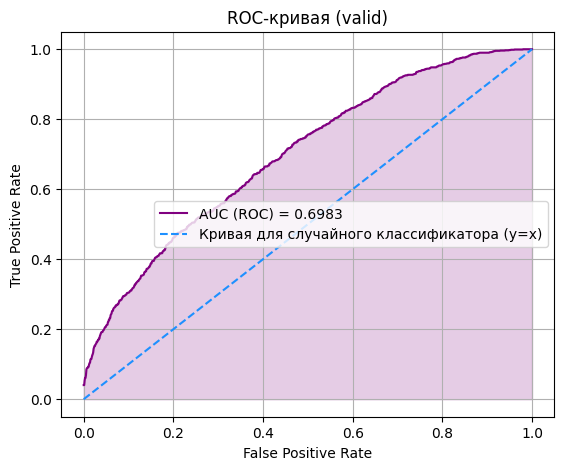

In [58]:
lb = LabelBinarizer().fit(y_train)
plot_curves(lb.transform(y_train), y_train_pred_proba, 'train')
plot_curves(lb.transform(y_val), y_val_pred_proba, 'valid')

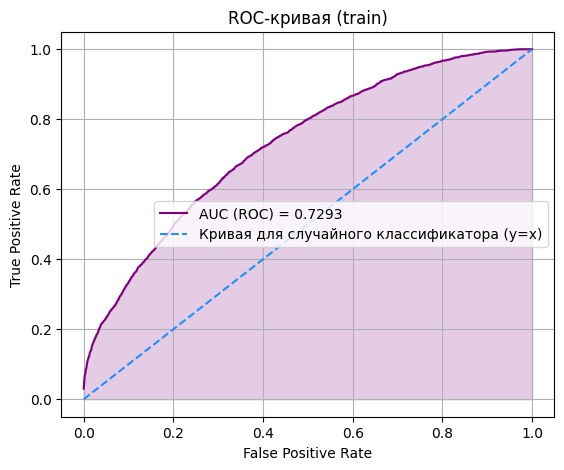

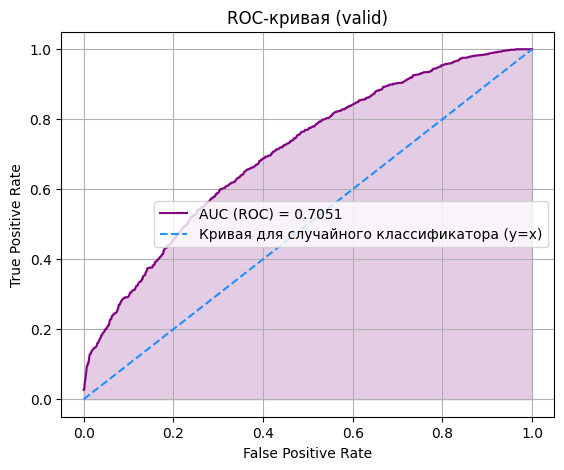

In [61]:
y_test_pred_proba = model_catboost_bow.predict_proba(X_test_combined)
plot_curves(lb.transform(y_train), y_train_pred_proba, 'train')
plot_curves(lb.transform(y_test), y_test_pred_proba, 'valid')

**Гиперпараметры**

Делал несколько запусков и сохранял результаты по частям:

In [48]:
%%time

sampler = TPESampler(seed=15)
def objective(trial, X_train_combined, y_train, X_val_combined, y_val):
    # Возмем более простые вычислительно границы гиперпараметров, чем в экспериментов над чистым TfIdf
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 1, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 1)
    # border_count = trial.suggest_int('border_count', 30, 130)
    min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 2, 20)
    # l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 3, 10)


    model_catboost_bow = CatBoostClassifier(n_estimators=n_estimators,
                                            max_depth=max_depth,
                                            learning_rate=learning_rate,
                                            #border_count=border_count,
                                            min_data_in_leaf=min_data_in_leaf,
                                            #l2_leaf_reg=l2_leaf_reg,
                                            random_state=42
    )


    model_catboost_bow.fit(X_train_combined, y_train, verbose=False)

    y_train_pred_proba = model_catboost_bow.predict_proba(X_train_combined)
    y_val_pred_proba = model_catboost_bow.predict_proba(X_val_combined)

    roc_auc_train = roc_auc_score(y_train, y_train_pred_proba,
        multi_class="ovr",
        average="micro"
    )
    roc_auc_val = roc_auc_score(y_val, y_val_pred_proba,
        multi_class="ovr",
        average="micro"
    )

    return [roc_auc_val, abs(roc_auc_train - roc_auc_val)]

study = optuna.create_study(sampler=sampler, directions=['maximize', 'minimize'])
study.optimize(lambda trial: objective(trial, X_train_combined, y_train, X_val_combined, y_val), n_trials=50, timeout=600)

[I 2026-05-13 15:31:26,063] A new study created in memory with name: no-name-fbf9f9a3-e610-48e3-8fae-0452e78018ba
[I 2026-05-13 15:32:24,948] Trial 0 finished with values: [0.732850070311758, 0.08248744115215234] and parameters: {'n_estimators': 440, 'max_depth': 2, 'learning_rate': 0.055308851092125, 'min_data_in_leaf': 8}.
[I 2026-05-13 15:34:40,552] Trial 1 finished with values: [0.7278393440040403, 0.2529618981261401] and parameters: {'n_estimators': 210, 'max_depth': 5, 'learning_rate': 0.3066129968201801, 'min_data_in_leaf': 7}.
[I 2026-05-13 15:34:52,233] Trial 2 finished with values: [0.6908634098538395, 0.188017601469612] and parameters: {'n_estimators': 144, 'max_depth': 2, 'learning_rate': 0.9177122679387258, 'min_data_in_leaf': 7}.
[W 2026-05-13 15:39:37,632] Trial 3 failed with parameters: {'n_estimators': 387, 'max_depth': 7, 'learning_rate': 0.8072724027631304, 'min_data_in_leaf': 6} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):


KeyboardInterrupt: 

In [50]:
study.trials_dataframe().to_csv('stylo_pt6.csv')

### BERT

**Код для Kaggle Notebooks**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vladislavkopchev/train-df/train.parquet
/kaggle/input/datasets/vladislavkopchev/val-df/val.parquet
/kaggle/input/datasets/vladislavkopchev/train-with-aug/train_with_aug.parquet


In [2]:
train_with_aug = pd.read_parquet('/kaggle/input/datasets/vladislavkopchev/train-with-aug/train_with_aug.parquet')

In [4]:
train_df = pd.read_parquet('/kaggle/input/datasets/vladislavkopchev/train-df/train.parquet')

In [5]:
val_df = pd.read_parquet('/kaggle/input/datasets/vladislavkopchev/val-df/val.parquet')

In [6]:
val_df.variable.replace(
    {'human_output': 0, 'model_output': 1, 'human_edits': 2},
    inplace=True
)

/tmp/ipykernel_57/4247686333.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  val_df.variable.replace(
/tmp/ipykernel_57/4247686333.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val_df.variable.replace(


In [7]:
train_df.variable.replace(
    {'human_output': 0, 'model_output': 1, 'human_edits': 2},
    inplace=True
)

/tmp/ipykernel_57/1257537691.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df.variable.replace(
/tmp/ipykernel_57/1257537691.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df.variable.replace(


In [8]:
train_df = train_df.iloc[:, [2, 1]]
val_df = val_df.iloc[:, [2, 1]]

In [9]:
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
# import evaluate

In [26]:
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 256
NUM_LABELS = 3
BATCH_SIZE = 1
EPOCHS = 4
LEARNING_RATE = 1e-7  # 2e-6?
WEIGHT_DECAY = 0.01

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification",
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      

In [12]:
from datasets import Dataset, DatasetDict

In [13]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df)
})

In [14]:
def tokenize_function(examples):
    tokens = tokenizer(
        examples["value"],
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )
    tokens["labels"] = examples["variable"]  # ВАЖНО
    return tokens

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/3936 [00:00<?, ? examples/s]

Map:   0%|          | 0/1314 [00:00<?, ? examples/s]

In [15]:
for example in tokenized_datasets['validation']:
    print(example)
    break

{'variable': 2, '__index_level_0__': 911, 'input_ids': [279, 1529, 490, 298, 8190, 328, 8393, 262, 27468, 261, 76282, 52508, 261, 324, 273, 1037, 1330, 291, 900, 292, 262, 949, 2758, 260, 672, 261, 970, 264, 262, 6155, 261, 76282, 284, 25452, 352, 262, 74696, 2427, 265, 10203, 267, 2097, 260], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 2}


In [18]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [19]:
import evaluate
roc_auc = evaluate.load("roc_auc", "multiclass")

In [20]:
import torch

In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    probabilities = torch.nn.functional.softmax(
        torch.Tensor(logits), dim=-1
    ).numpy().astype(np.float32)
    labels = np.array(labels).astype(np.int32)
    
    res = roc_auc.compute(
        prediction_scores=probabilities,
        references=labels,
        multi_class="ovr"
    )
    return {"roc_auc": res["roc_auc"]}

In [24]:
train_with_aug = pd.read_parquet('/kaggle/input/datasets/vladislavkopchev/train-with-aug2/train_with_aug.parquet')
test_df = pd.read_parquet('/kaggle/input/datasets/vladislavkopchev/test-df/test.parquet')
test_df.variable.replace(
    {'human_output': 0, 'model_output': 1, 'human_edits': 2},
    inplace=True
)
test_df = test_df.iloc[:, [2, 1]]

test_dataset = DatasetDict({
    "test": Dataset.from_pandas(test_df),
})

tokenized_test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

/tmp/ipykernel_57/1577692488.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df.variable.replace(
/tmp/ipykernel_57/1577692488.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df.variable.replace(


Map:   0%|          | 0/1311 [00:00<?, ? examples/s]

**Эксперимент 1**

TODO: для обычный роберты просто поменяю `MODEL_NAME`.

In [138]:
not_third_model = (train_with_aug.model_name == 'model2')
original_texts = (train_with_aug.model_name.isna())
filtered_augs = (train_with_aug.cosine_sim > 0.9) & (train_with_aug.cosine_sim < 1)
# TODO x2: потом 0.85–0.9, 0.78–0.85

filtering_criteria = not_third_model & (original_texts | filtered_augs)

filtering_criteria1 = (~train_with_aug.cosine_sim.isna()) & filtering_criteria
filtering_criteria2 = (train_with_aug.cosine_sim.isna())

In [139]:
aug_exp_dataset = DatasetDict({
    "aug": Dataset.from_pandas(
        train_with_aug.loc[filtering_criteria1, ['value', 'variable']]
    ),
    "orig": Dataset.from_pandas(
        train_with_aug.loc[filtering_criteria2, ['value', 'variable']]
    )
})


In [140]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 3 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [141]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4336 [00:00<?, ? examples/s]

In [142]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification",
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      

In [143]:
training_args1 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1.3e-7,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [144]:
trainer1 = Trainer(
    model=model,
    args=training_args1,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer1.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,4.278418,2.003906,0.682237
2,3.845557,2.181641,0.716036


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1968, training_loss=4.120923732354389, metrics={'train_runtime': 897.7132, 'train_samples_per_second': 8.769, 'train_steps_per_second': 2.192, 'total_flos': 798827689672740.0, 'train_loss': 4.120923732354389, 'epoch': 2.0})

In [145]:
trainer1.save_model('./step1')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [146]:
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [147]:
training_args2 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-8,  # new
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

TODO: соберу материалы для графика кривой обучения с / без аугментаций

In [148]:
trainer2 = Trainer(
    model=model_step2,
    args=training_args2,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer2.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

# Нашлась ошибка в критериях для фильтрации :( запускаем заново эти 200...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,4.358252,2.156250,0.724245
2,3.132764,2.498047,0.735188


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.6309227468342797, metrics={'train_runtime': 976.5554, 'train_samples_per_second': 8.88, 'train_steps_per_second': 2.22, 'total_flos': 839380772433060.0, 'train_loss': 3.6309227468342797, 'epoch': 2.0})

In [149]:
trainer2.save_model('./step2')
# Теперь пробуем разное

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [150]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [151]:
training_args3 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-8,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [152]:
trainer3 = Trainer(
    model=model_step3,
    args=training_args3,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer3.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.547314,2.939453,0.711163
2,2.065210,3.162109,0.717147


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.1049214465151853, metrics={'train_runtime': 997.8876, 'train_samples_per_second': 8.69, 'train_steps_per_second': 2.173, 'total_flos': 839380772433060.0, 'train_loss': 3.1049214465151853, 'epoch': 2.0})

In [153]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 4 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [154]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

In [155]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [156]:
training_args4 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1e-9,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [157]:
trainer4 = Trainer(
    model=model_step3,
    args=training_args4,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer4.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.138086,2.171875,0.724762
2,3.446484,2.171875,0.724875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2368, training_loss=3.418920207667995, metrics={'train_runtime': 1046.8459, 'train_samples_per_second': 9.048, 'train_steps_per_second': 2.262, 'total_flos': 889034042611260.0, 'train_loss': 3.418920207667995, 'epoch': 2.0})

In [158]:
trainer1.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.017578125,
 'eval_roc_auc': 0.6728264796904209,
 'eval_runtime': 57.3584,
 'eval_samples_per_second': 22.856,
 'eval_steps_per_second': 11.437,
 'epoch': 2.0}

In [159]:
trainer2.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.212890625,
 'eval_roc_auc': 0.7152103220941619,
 'eval_runtime': 56.8761,
 'eval_samples_per_second': 23.05,
 'eval_steps_per_second': 11.534,
 'epoch': 2.0}

In [160]:
trainer3.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 3.064453125,
 'eval_roc_auc': 0.6945664828672018,
 'eval_runtime': 56.7785,
 'eval_samples_per_second': 23.09,
 'eval_steps_per_second': 11.554,
 'epoch': 2.0}

In [161]:
trainer4.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.2265625,
 'eval_roc_auc': 0.7159800805366316,
 'eval_runtime': 56.2334,
 'eval_samples_per_second': 23.314,
 'eval_steps_per_second': 11.666,
 'epoch': 2.0}

**Эксперимент 2**

In [174]:
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [175]:
training_args2 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-8,  # new
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

TODO: соберу материалы для графика кривой обучения с / без аугментаций

In [176]:
trainer2 = Trainer(
    model=model_step2,
    args=training_args2,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer2.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

# Нашлась ошибка в критериях для фильтрации :( запускаем заново эти 200...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,4.306250,2.070312,0.728932
2,3.605737,2.595703,0.740625


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.7113587495585647, metrics={'train_runtime': 975.887, 'train_samples_per_second': 8.886, 'train_steps_per_second': 2.222, 'total_flos': 841174292541960.0, 'train_loss': 3.7113587495585647, 'epoch': 2.0})

In [177]:
trainer2.save_model('./step2')
# Теперь пробуем разное

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [178]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [179]:
training_args3 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-8,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [180]:
trainer3 = Trainer(
    model=model_step3,
    args=training_args3,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer3.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.355737,2.460938,0.734337
2,2.705188,3.197266,0.725813


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.123091124080644, metrics={'train_runtime': 987.8586, 'train_samples_per_second': 8.779, 'train_steps_per_second': 2.195, 'total_flos': 841174292541960.0, 'train_loss': 3.123091124080644, 'epoch': 2.0})

In [181]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 4 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [182]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

In [183]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [184]:
training_args4 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1e-9,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [185]:
trainer4 = Trainer(
    model=model_step3,
    args=training_args4,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer4.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.542041,2.160156,0.726023
2,3.868262,2.171875,0.725676


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2368, training_loss=3.7023168770042627, metrics={'train_runtime': 1082.6436, 'train_samples_per_second': 8.749, 'train_steps_per_second': 2.187, 'total_flos': 892291157353440.0, 'train_loss': 3.7023168770042627, 'epoch': 2.0})

In [186]:
trainer1.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.3515625, 'eval_roc_auc': 0.44820712611296426}

In [187]:
trainer2.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.1328125,
 'eval_roc_auc': 0.7252276547502473,
 'eval_runtime': 57.9433,
 'eval_samples_per_second': 22.626,
 'eval_steps_per_second': 11.321,
 'epoch': 2.0}

In [188]:
trainer3.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.56640625,
 'eval_roc_auc': 0.7212309327691928,
 'eval_runtime': 56.95,
 'eval_samples_per_second': 23.02,
 'eval_steps_per_second': 11.519,
 'epoch': 2.0}

In [189]:
trainer4.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.224609375,
 'eval_roc_auc': 0.721432536170792,
 'eval_runtime': 56.6376,
 'eval_samples_per_second': 23.147,
 'eval_steps_per_second': 11.582,
 'epoch': 2.0}

**Эксперимент 3**

In [46]:
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [47]:
training_args2 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-8,  # new
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

TODO: соберу материалы для графика кривой обучения с / без аугментаций

In [48]:
trainer2 = Trainer(
    model=model_step2,
    args=training_args2,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer2.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

# Нашлась ошибка в критериях для фильтрации :( запускаем заново эти 200...

Epoch,Training Loss,Validation Loss,Roc Auc
1,4.171729,2.201172,0.726934
2,3.397534,2.423828,0.735078


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.7327025578910575, metrics={'train_runtime': 1009.6331, 'train_samples_per_second': 8.589, 'train_steps_per_second': 2.147, 'total_flos': 841000593459780.0, 'train_loss': 3.7327025578910575, 'epoch': 2.0})

In [49]:
trainer2.save_model('./step2')
# Теперь пробуем разное

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [51]:
training_args3 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-8,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [52]:
trainer3 = Trainer(
    model=model_step3,
    args=training_args3,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer3.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

Epoch,Training Loss,Validation Loss,Roc Auc
1,3.726514,3.146484,0.717137
2,2.116931,3.154297,0.729889


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.217153887027304, metrics={'train_runtime': 1006.5164, 'train_samples_per_second': 8.616, 'train_steps_per_second': 2.154, 'total_flos': 841000593459780.0, 'train_loss': 3.217153887027304, 'epoch': 2.0})

In [53]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 4 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [54]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

In [55]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [56]:
training_args4 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1e-9,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [57]:
trainer4 = Trainer(
    model=model_step3,
    args=training_args4,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer4.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

Epoch,Training Loss,Validation Loss,Roc Auc
1,3.184607,2.216797,0.726805
2,3.862842,2.218750,0.726795


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2368, training_loss=3.5826734078897013, metrics={'train_runtime': 1088.6364, 'train_samples_per_second': 8.701, 'train_steps_per_second': 2.175, 'total_flos': 892020844580580.0, 'train_loss': 3.5826734078897013, 'epoch': 2.0})

In [58]:
trainer1.evaluate(eval_dataset=tokenized_test_dataset["test"])

NameError: name 'trainer1' is not defined

In [ ]:
trainer2.evaluate(eval_dataset=tokenized_test_dataset["test"])

In [ ]:
trainer3.evaluate(eval_dataset=tokenized_test_dataset["test"])

In [ ]:
trainer4.evaluate(eval_dataset=tokenized_test_dataset["test"])

**Эксперимент 4**

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

Epoch,Training Loss,Validation Loss,Roc Auc
1,3.925000,2.019531,0.683315
2,3.887256,2.078125,0.716147
3,3.702075,2.056641,0.714204
4,3.360596,2.345703,0.723224
5,1.640295,3.060547,0.692501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


KeyboardInterrupt: 

In [25]:
trainer.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 3.060546875, 'eval_roc_auc': 0.6925007025573087}

**Перед экспериментами 5–8**

Перезапустить код, приведенный в самом начале ноутбука, с новыми параметрами, чтобы обновить `model` и `tokenizer`:

In [9]:
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 256
NUM_LABELS = 3
BATCH_SIZE = 1
EPOCHS = 4
LEARNING_RATE = 1e-7  # 2e-6?
WEIGHT_DECAY = 0.01

**Эксперимент 5**

distilled 

TODO: для обычный роберты просто поменяю `MODEL_NAME`.

Сначала надо запустить много всего наверху

In [21]:
from datasets import concatenate_datasets

In [22]:
# MODEL_NAME = ... # see up BERT

In [23]:
not_third_model = (train_with_aug.model_name == 'model2')
original_texts = (train_with_aug.model_name.isna())
filtered_augs = (train_with_aug.cosine_sim > 0.9) & (train_with_aug.cosine_sim < 1)
# 1-0.9 0.83–0.9, 0.75–0.83

filtering_criteria = not_third_model & (original_texts | filtered_augs)

filtering_criteria1 = (~train_with_aug.cosine_sim.isna()) & filtering_criteria
filtering_criteria2 = (train_with_aug.cosine_sim.isna())

In [24]:
aug_exp_dataset = DatasetDict({
    "aug": Dataset.from_pandas(
        train_with_aug.loc[filtering_criteria1, ['value', 'variable']]
    ),
    "orig": Dataset.from_pandas(
        train_with_aug.loc[filtering_criteria2, ['value', 'variable']]
    )
})


In [25]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 3 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [26]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4336 [00:00<?, ? examples/s]

In [27]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification",
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
training_args1 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1.3e-5,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [29]:
trainer1 = Trainer(
    model=model,
    args=training_args1,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer1.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.087493,1.804225,0.764162
2,3.131662,1.804128,0.784983


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1968, training_loss=3.606436786612844, metrics={'train_runtime': 476.0257, 'train_samples_per_second': 16.537, 'train_steps_per_second': 4.134, 'total_flos': 414993091467924.0, 'train_loss': 3.606436786612844, 'epoch': 2.0})

In [30]:
trainer1.save_model('./step1')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [34]:
training_args2 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-6,  # new
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

TODO: соберу материалы для графика кривой обучения с / без аугментаций

In [35]:
trainer2 = Trainer(
    model=model_step2,
    args=training_args2,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer2.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

# Нашлась ошибка в критериях для фильтрации :( запускаем заново эти 200...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.171176,1.906995,0.799215
2,2.513111,2.018535,0.805666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.028874015456196, metrics={'train_runtime': 513.5593, 'train_samples_per_second': 16.886, 'train_steps_per_second': 4.222, 'total_flos': 437037405098328.0, 'train_loss': 3.028874015456196, 'epoch': 2.0})

In [36]:
trainer2.save_model('./step2')
# Теперь пробуем разное

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [38]:
training_args3 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-6,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [39]:
trainer3 = Trainer(
    model=model_step3,
    args=training_args3,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer3.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,2.545214,2.627036,0.797856
2,2.446303,2.763947,0.801182


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=2.3892877330639264, metrics={'train_runtime': 516.9808, 'train_samples_per_second': 16.774, 'train_steps_per_second': 4.194, 'total_flos': 437037405098328.0, 'train_loss': 2.3892877330639264, 'epoch': 2.0})

In [40]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 4 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [41]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

In [42]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [43]:
training_args4 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1e-7,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [44]:
trainer4 = Trainer(
    model=model_step3,
    args=training_args4,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer4.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,2.757234,1.898256,0.800313
2,3.211372,1.900335,0.800416


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2368, training_loss=2.8568921999351398, metrics={'train_runtime': 560.1506, 'train_samples_per_second': 16.91, 'train_steps_per_second': 4.227, 'total_flos': 463668484204188.0, 'train_loss': 2.8568921999351398, 'epoch': 2.0})

In [45]:
trainer1.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.8078203201293945,
 'eval_roc_auc': 0.7834500189385013,
 'eval_runtime': 29.7445,
 'eval_samples_per_second': 44.075,
 'eval_steps_per_second': 22.054,
 'epoch': 2.0}

это от предыдущих exp будет?

In [46]:
trainer2.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.9162230491638184,
 'eval_roc_auc': 0.7989769718296338,
 'eval_runtime': 30.0508,
 'eval_samples_per_second': 43.626,
 'eval_steps_per_second': 21.83,
 'epoch': 2.0}

In [47]:
trainer3.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.583937406539917,
 'eval_roc_auc': 0.8021397888313461,
 'eval_runtime': 29.642,
 'eval_samples_per_second': 44.228,
 'eval_steps_per_second': 22.131,
 'epoch': 2.0}

In [48]:
trainer4.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.904284954071045,
 'eval_roc_auc': 0.80023633853313,
 'eval_runtime': 30.0282,
 'eval_samples_per_second': 43.659,
 'eval_steps_per_second': 21.846,
 'epoch': 2.0}

**Эксперимент 6**

distilled 

In [57]:
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [58]:
training_args2 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-6,  # new
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

TODO: соберу материалы для графика кривой обучения с / без аугментаций

In [59]:
trainer2 = Trainer(
    model=model_step2,
    args=training_args2,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer2.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

# Нашлась ошибка в критериях для фильтрации :( запускаем заново эти 200...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.696384,1.895654,0.795155
2,2.880328,2.011825,0.806482


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.0855698761464927, metrics={'train_runtime': 516.8807, 'train_samples_per_second': 16.778, 'train_steps_per_second': 4.194, 'total_flos': 437936750585280.0, 'train_loss': 3.0855698761464927, 'epoch': 2.0})

In [60]:
trainer2.save_model('./step2')
# Теперь пробуем разное

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [61]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [62]:
training_args3 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-6,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [63]:
trainer3 = Trainer(
    model=model_step3,
    args=training_args3,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer3.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.098391,2.364350,0.797460
2,2.799510,2.655172,0.801910


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=2.4243335921825957, metrics={'train_runtime': 516.2078, 'train_samples_per_second': 16.799, 'train_steps_per_second': 4.2, 'total_flos': 437936750585280.0, 'train_loss': 2.4243335921825957, 'epoch': 2.0})

In [64]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 4 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [65]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

In [66]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [67]:
training_args4 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1e-7,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [68]:
trainer4 = Trainer(
    model=model_step3,
    args=training_args4,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer4.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,2.409320,1.882984,0.798235
2,3.168429,1.882582,0.798590


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2368, training_loss=2.9947665051834003, metrics={'train_runtime': 557.9824, 'train_samples_per_second': 16.975, 'train_steps_per_second': 4.244, 'total_flos': 465321251456964.0, 'train_loss': 2.9947665051834003, 'epoch': 2.0})

In [69]:
trainer1.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.199256181716919, 'eval_roc_auc': 0.5468260991749098}

это от предыдущих exp будет?

In [70]:
trainer2.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.8919709920883179,
 'eval_roc_auc': 0.7975866938263977,
 'eval_runtime': 29.4501,
 'eval_samples_per_second': 44.516,
 'eval_steps_per_second': 22.275,
 'epoch': 2.0}

In [71]:
trainer3.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.311511993408203,
 'eval_roc_auc': 0.8041305133293886,
 'eval_runtime': 29.9399,
 'eval_samples_per_second': 43.788,
 'eval_steps_per_second': 21.911,
 'epoch': 2.0}

In [72]:
trainer4.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.8785736560821533,
 'eval_roc_auc': 0.7997380028521208,
 'eval_runtime': 29.8225,
 'eval_samples_per_second': 43.96,
 'eval_steps_per_second': 21.997,
 'epoch': 2.0}

**Эксперимент 7**

distilled 

In [78]:
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [79]:
training_args2 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-6,  # new
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

TODO: соберу материалы для графика кривой обучения с / без аугментаций

In [80]:
trainer2 = Trainer(
    model=model_step2,
    args=training_args2,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer2.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

# Нашлась ошибка в критериях для фильтрации :( запускаем заново эти 200...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,3.487880,1.843020,0.800300
2,2.635797,1.988155,0.807648


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=3.12188556141519, metrics={'train_runtime': 514.1914, 'train_samples_per_second': 16.865, 'train_steps_per_second': 4.216, 'total_flos': 437834293504488.0, 'train_loss': 3.12188556141519, 'epoch': 2.0})

In [81]:
trainer2.save_model('./step2')
# Теперь пробуем разное

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [82]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [83]:
training_args3 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=9e-6,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [84]:
trainer3 = Trainer(
    model=model_step3,
    args=training_args3,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer3.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,2.762580,2.397472,0.802564
2,2.323966,2.522742,0.808240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2168, training_loss=2.4809305887820536, metrics={'train_runtime': 514.0611, 'train_samples_per_second': 16.87, 'train_steps_per_second': 4.217, 'total_flos': 437834293504488.0, 'train_loss': 2.4809305887820536, 'epoch': 2.0})

In [85]:
dataset_concat = concatenate_datasets(
    [
        aug_exp_dataset['aug'].shuffle(seed=42).select(range(2 * 400, 4 * 400)),
        aug_exp_dataset['orig']
    ]
)

In [86]:
tokenized_dataset_concat = dataset_concat.map(
    tokenize_function,
    batched=True,
    remove_columns=["value"],
)

Map:   0%|          | 0/4736 [00:00<?, ? examples/s]

In [87]:
model_step3 = AutoModelForSequenceClassification.from_pretrained(
    './step2'
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [88]:
training_args4 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1e-7,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)

In [89]:
trainer4 = Trainer(
    model=model_step3,
    args=training_args4,
    train_dataset=tokenized_dataset_concat,
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer4.train()  # выбрал accelerator GPT T4 x2, Kaggle Notebooks

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,2.797749,1.871955,0.801447
2,3.775874,1.872049,0.801719


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2368, training_loss=3.049960980544219, metrics={'train_runtime': 555.0838, 'train_samples_per_second': 17.064, 'train_steps_per_second': 4.266, 'total_flos': 465072870655044.0, 'train_loss': 3.049960980544219, 'epoch': 2.0})

In [90]:
trainer1.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.199256181716919, 'eval_roc_auc': 0.5468260991749098}

это от предыдущих exp будет?

In [91]:
trainer2.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.8549138307571411,
 'eval_roc_auc': 0.7979200812697349,
 'eval_runtime': 29.5388,
 'eval_samples_per_second': 44.382,
 'eval_steps_per_second': 22.208,
 'epoch': 2.0}

In [92]:
trainer3.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.424764394760132,
 'eval_roc_auc': 0.8014551227337073,
 'eval_runtime': 30.0006,
 'eval_samples_per_second': 43.699,
 'eval_steps_per_second': 21.866,
 'epoch': 2.0}

In [93]:
trainer4.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.8907115459442139,
 'eval_roc_auc': 0.7986226385783383,
 'eval_runtime': 29.9776,
 'eval_samples_per_second': 43.733,
 'eval_steps_per_second': 21.883,
 'epoch': 2.0}

**Эксперимент 8**

distilled 

`trainer5`

In [94]:
# TODO: trainer5 как четвертый эксперимент в первой группе, еще 6 эпох
model_step2 = AutoModelForSequenceClassification.from_pretrained(
    './step1'
)
training_args5 = TrainingArguments(
    output_dir="./my-deberta-model",
    num_train_epochs=6,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=1.3e-5,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    logging_steps=10,
    eval_steps=None,
    report_to="none",
)
trainer5 = Trainer(
    model=model_step2,
    args=training_args5,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer5.train()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Roc Auc
1,2.552239,1.957660,0.795958
2,2.489491,2.227280,0.803082
3,1.130734,3.126371,0.806848


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


KeyboardInterrupt: 

In [96]:
trainer5.evaluate(eval_dataset=tokenized_test_dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 3.126370906829834, 'eval_roc_auc': 0.8068482319119857}